# Spring of Code - Artificial Intelligence
## Week 06: Advanced Machine Learning Models

### Day 03: Support Vector Machines and Decision Trees

In this notebook, we will explore **Support Vector Machines (SVM)** and **Decision Trees** using Python's Scikit-Learn library.


# Support Vector Machines (SVM)
A powerful machine learning algorithm used for classification and regression tasks.


In [1]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
type(iris)

sklearn.utils._bunch.Bunch

In [2]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
iris.data.values

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [6]:
iris.target.values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
X = iris.data.values
y = iris.target.values
print(f"Features' shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features' shape: (150, 4)
Target shape: (150,)


In [13]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [9]:
X = X[:100]
y = y[:100]
print(f"Features' shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features' shape: (100, 4)
Target shape: (100,)


In [10]:
iris.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


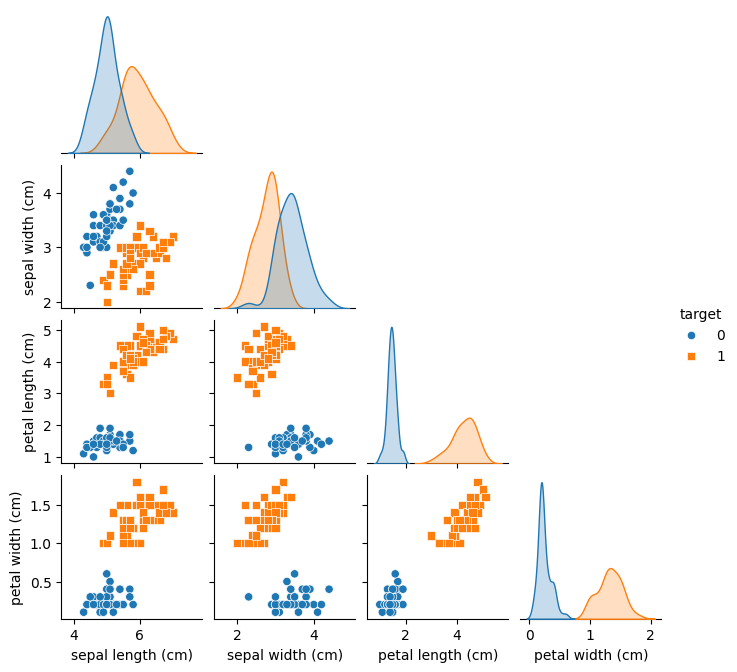

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    iris.frame.iloc[:100], hue="target", markers=["o", "s"], corner=True, height=1.7
)
plt.show()

## Linear SVM Classification
In linear SVM, the goal is to find the optimal hyperplane that separates different classes in the feature space. The hyperplane is chosen to maximize the margin between the classes.

<img src="linear_svm.png" alt="Linear SVM" width="800">

### Soft Margin Classification
In real-world scenarios, data is often not perfectly separable. Soft margin SVM allows some misclassifications by introducing slack variables. The objective is to find a balance between maximizing the margin and minimizing classification errors.

<img src="soft_margin_classification.png" alt="Soft Margin SVM" width="800">

In [14]:
from sklearn.svm import LinearSVC


model = LinearSVC(C=1)
model.fit(X, y)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [16]:
model.score(X, y)* 100

100.0

In [17]:
X.shape

(100, 4)

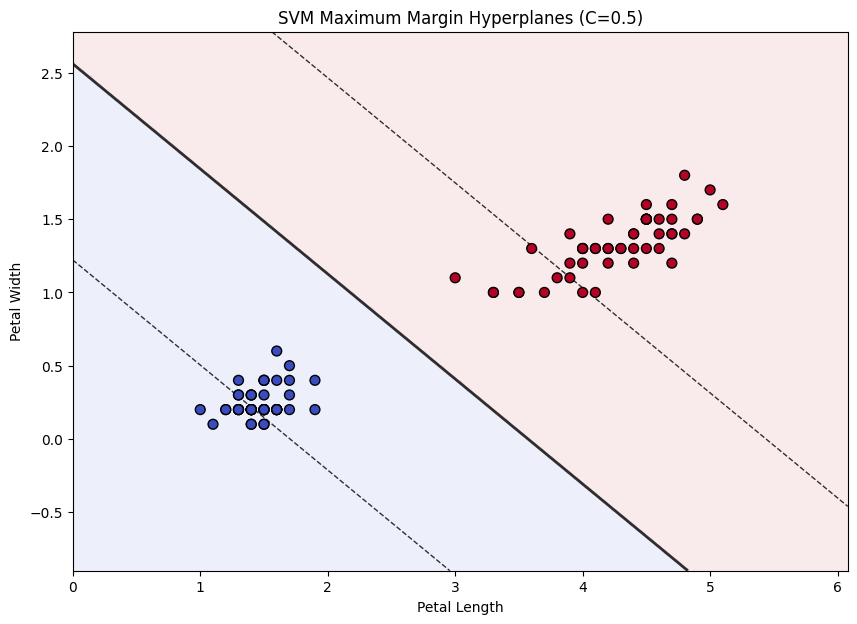

In [21]:
# Use only petal length & petal width for 2D visualization
X_2d = X[:, 2:4]

model_2d = LinearSVC(C=0.5)
model_2d.fit(X_2d, y)

# Visualize the decision boundary
import numpy as np
def plot_decision_boundary(model, X, y):
    # 1. Setup Grid
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 2. Get predictions and distances
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z_pred = model.predict(grid_points).reshape(xx.shape)
    Z_dist = model.decision_function(grid_points)

    plt.figure(figsize=(10, 7))

    # 3. Plot Regions (Very light alpha)
    plt.contourf(xx, yy, Z_pred, alpha=0.1, cmap='coolwarm')

    # 4. Draw the Hyperplanes AND Margins
    # Levels [-1, 0, 1] represent the margins and the central hyperplane
    if Z_dist.ndim == 1:
        # BINARY CASE
        zz = Z_dist.reshape(xx.shape)
        plt.contour(xx, yy, zz, levels=[-1, 0, 1], colors='k', 
                    linestyles=['--', '-', '--'], alpha=0.8, linewidths=[1, 2, 1])
    else:
        # MULTICLASS CASE (One-vs-Rest)
        for i in range(Z_dist.shape[1]):
            zz = Z_dist[:, i].reshape(xx.shape)
            plt.contour(xx, yy, zz, levels=[-1, 0, 1], colors='k', 
                        linestyles=['--', '-', '--'], alpha=0.5, linewidths=[1, 2, 1])

    # 5. Plot Data
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm', s=50, zorder=3)
    
    plt.title(f"SVM Maximum Margin Hyperplanes (C={model.C})")
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")
    plt.show()
plot_decision_boundary(model_2d, X_2d, y)

## Impact of C

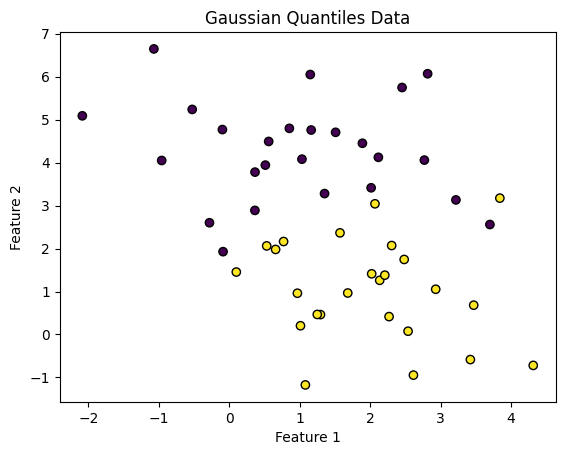

In [22]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, n_features=2, random_state=0, cluster_std=1.2)

# Visualize the Gaussian data
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Gaussian Quantiles Data")
plt.show()

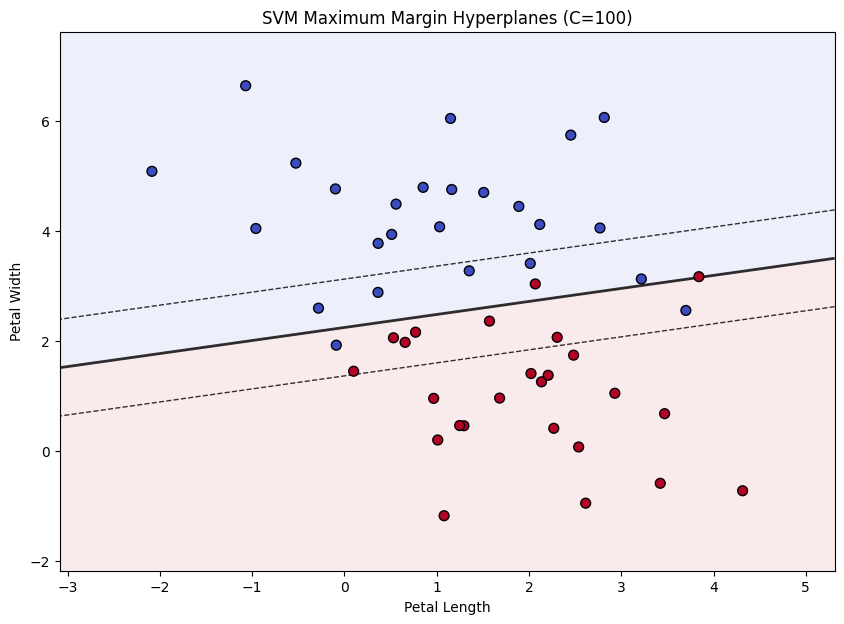

In [26]:
model = LinearSVC(C=100)
model.fit(X, y)
plot_decision_boundary(model, X, y)

## Non-Linear SVM Classification
When data is not linearly separable, SVM can use kernel functions to transform the data into a higher-dimensional space where a linear separation is possible.

In [28]:
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=300,
    noise=0.1, random_state=42, factor=0.1
)
X.shape, y.shape

((300, 2), (300,))

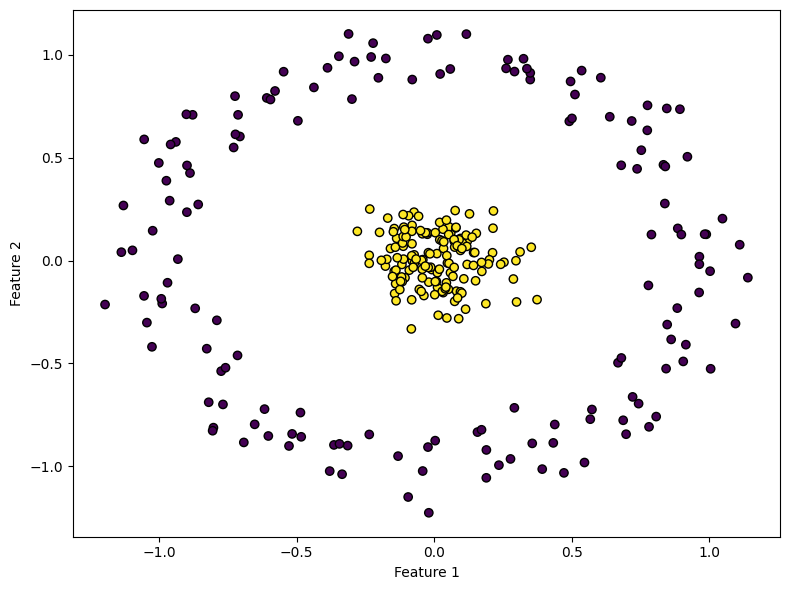

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

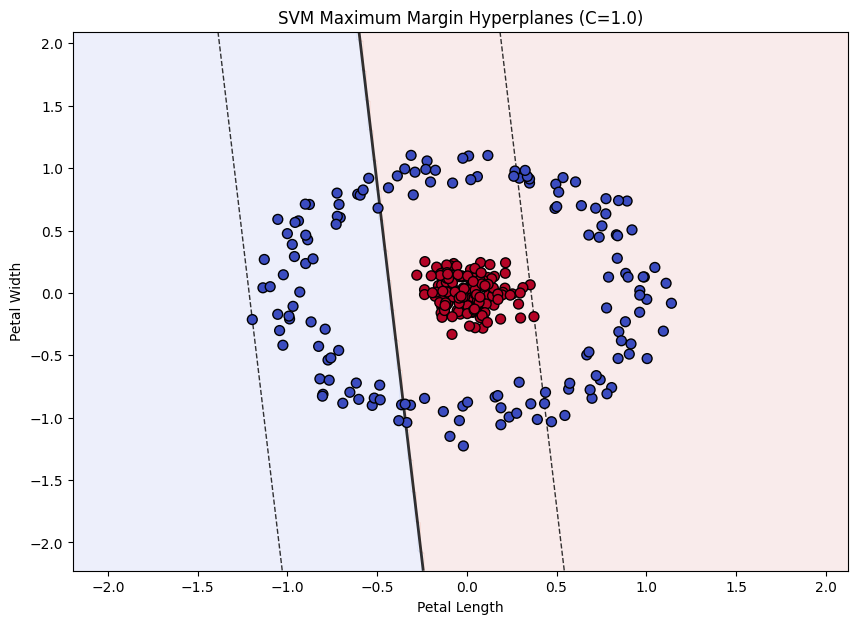

Model Accuracy: 0.68


In [30]:

from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X, y)
plot_decision_boundary(model, X, y)
print(f"Model Accuracy: {model.score(X, y):.2f}")

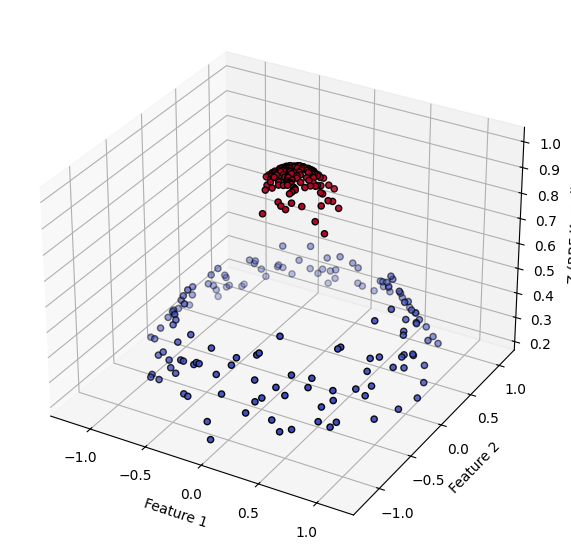

In [31]:
z_values = np.exp(-(X[:, 0]**2 + X[:, 1]**2))

# 3D Scatter Plot with plt.3Dscatter

ax = plt.figure(figsize=(10, 7)).add_subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], z_values, c=y, edgecolors='k', cmap='coolwarm')
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Z (RBF Kernel)")
plt.show()


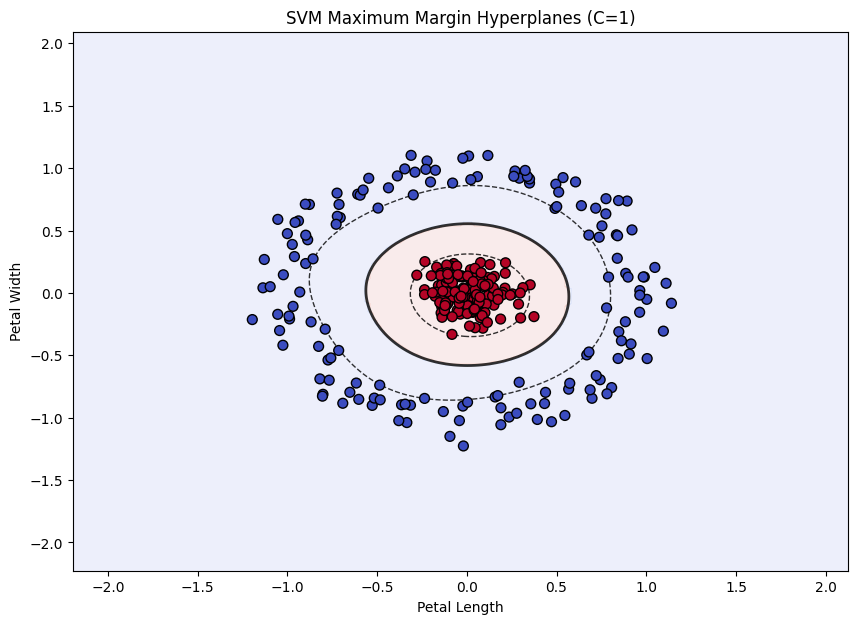

Model Accuracy: 1.00


In [37]:
model = SVC(kernel='rbf', C=1)
model.fit(X, y)
plot_decision_boundary(model, X, y)
print(f"Model Accuracy: {model.score(X, y):.2f}")

In [38]:
model.score(X, y)

1.0

In [39]:
X[0]

array([0.06047829, 0.13344899])

In [40]:
y[0]

np.int64(1)

In [41]:
import numpy as np


X_new = np.array([
    [0.06, 0.14]
])

model.predict(X_new)

array([1])

In [42]:
model.score(X, y)

1.0

## Kernels
A kernel is a function that computes the similarity between two data points in the transformed feature space without explicitly performing the transformation. Common kernels include polynomial and radial basis function (RBF) kernels.

## SVM Regression
SVM can also be used for regression tasks.


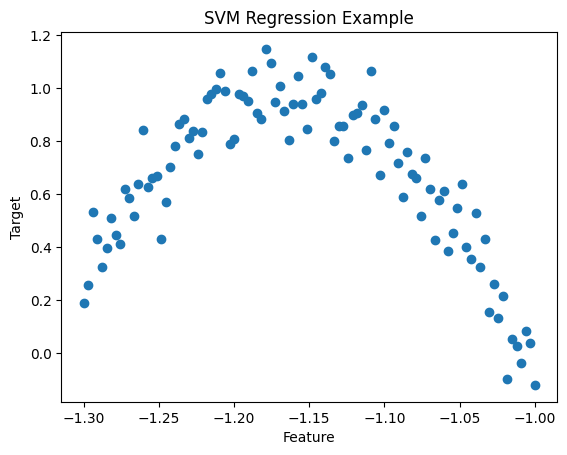

In [43]:
X = np.linspace(-1, -1.3, 100)
y = np.sin(3 * np.pi * X) + np.random.normal(0, 0.1, X.shape)

plt.scatter(X, y)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("SVM Regression Example")
plt.show()

In [56]:
from sklearn.svm import SVR

model = SVR(kernel="rbf", C=10, epsilon=0.001)
model.fit(X.reshape(-1, 1), y)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.001
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


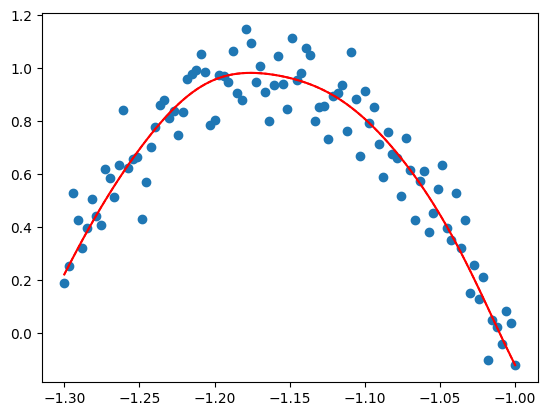

In [57]:
y_pred = model.predict(X.reshape(-1, 1))

plt.scatter(X, y)
plt.plot(X, y_pred, color="red")
plt.plot(X, y_pred + model.epsilon, "r--", lw=1, label="Margin (+epsilon)")
plt.plot(X, y_pred - model.epsilon, "r--", lw=1, label="Margin (-epsilon)")
# plt.legend()
plt.show()

In [58]:
model.epsilon

0.001

In [59]:
import pandas as pd

data = pd.read_csv(r'D:\NAVTTC-AI-Course\datasets\stroke_data.csv')
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [61]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [62]:
data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [65]:
data['bmi'].fillna(data['bmi'].mean(), inplace=True)

C:\Users\asadu\AppData\Local\Temp\ipykernel_3200\3685616333.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bmi'].fillna(data['bmi'].mean(), inplace=True)


In [66]:
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [74]:
clean_data = pd.get_dummies(data, drop_first=True)

In [75]:
X = clean_data.drop('stroke', axis=1).values
y = clean_data['stroke'].values

print(f"Features' shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features' shape: (5110, 17)
Target shape: (5110,)


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (4088, 17)
Training target shape: (4088,)
Testing features shape: (1022, 17)
Testing target shape: (1022,)


In [77]:
from sklearn.svm import SVC
model = SVC(kernel='rbf', C=1)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9393346379647749

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

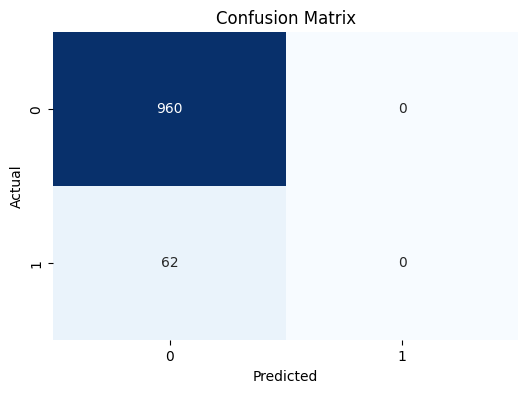

In [78]:
preds = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

# Visualize the confusion matrix
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [83]:
np.unique(y_train, return_counts=True)

(array([0, 1]), array([3901,  187]))